In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from word2number import w2n
import math
import seaborn as sns

## Single variable Linear Reg

In [2]:
df = pd.read_csv("canada_per_capita_income.csv")
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


[]

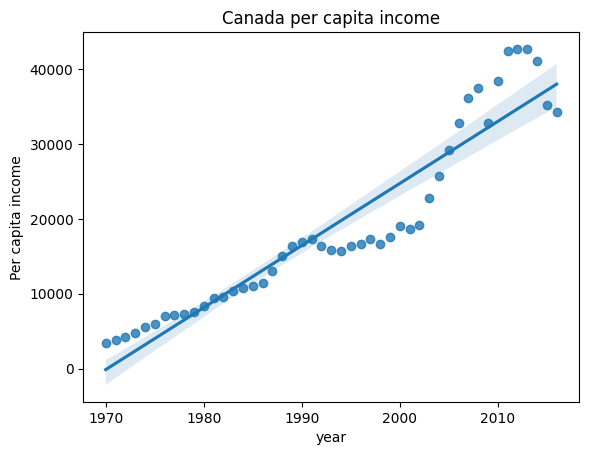

In [3]:
sns.regplot(x=df["year"], y=df["per capita income (US$)"])
plt.xlabel("year")
plt.ylabel("Per capita income")
plt.title("Canada per capita income")
plt.plot()

In [4]:
# 
reg = linear_model.LinearRegression()
reg.fit(df[["year"]], df["per capita income (US$)"])

LinearRegression()

In [5]:
# passing based on coefficient 
reg.predict([[2020], [2021]])

/home/Jatin/Documents/Machine Learning files/envml/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442, 42117.15916964])

# Multiple Linear Reg

In [6]:
dfm = pd.read_csv("hiring.csv")
dfm.head()


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [7]:
dfm["experience"] = dfm["experience"].fillna("zero")
dfm

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [8]:
dfm.experience = dfm.experience.apply(w2n.word_to_num)
dfm

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [9]:
dfm.info()
dfm.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   experience                  8 non-null      int64  
 1   test_score(out of 10)       7 non-null      float64
 2   interview_score(out of 10)  8 non-null      int64  
 3   salary($)                   8 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 388.0 bytes


Index(['experience', 'test_score(out of 10)', 'interview_score(out of 10)',
       'salary($)'],
      dtype='object')

In [10]:
mid = dfm["test_score(out of 10)"].median()
dfm["test_score(out of 10)"] = dfm["test_score(out of 10)"].fillna(mid)

In [11]:
reg.fit(dfm[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']], dfm["salary($)"])

LinearRegression()

In [12]:
print(f"if 2year exp, 9 test_score, 6 interview_score , salary will be: {reg.predict([ [2,9,6] ])}")
print(f"if 12year exp, 10 test_score, 10 interview_score , salary will be: {reg.predict([ [12,10,10]] )}")
print(" \n ")

if 2year exp, 9 test_score, 6 interview_score , salary will be: [53205.96797671]
if 12year exp, 10 test_score, 10 interview_score , salary will be: [92002.18340611]
 
 


/home/Jatin/Documents/Machine Learning files/envml/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/Jatin/Documents/Machine Learning files/envml/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
